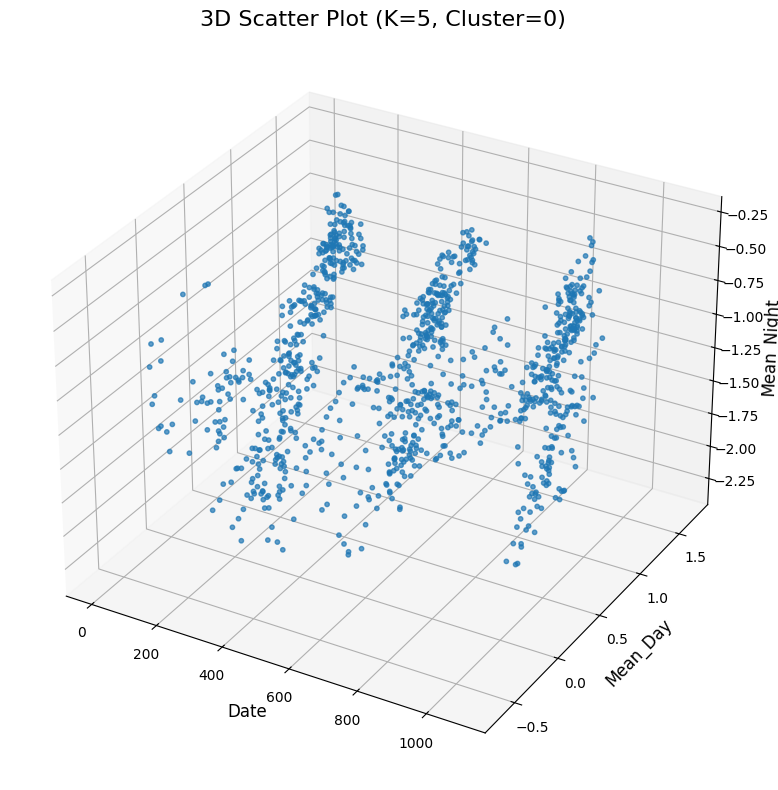

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_scatter(csv_path, K, cluster):
    # 读取三维数据
    df = pd.read_csv(csv_path)

    # 创建 3D 图
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # 散点图
    ax.scatter(
        df["Date"], 
        df["Mean_Day"], 
        df["Mean_Night"], 
        s=10, 
        alpha=0.7
    )

    # 标签
    ax.set_title(f"3D Scatter Plot (K={K}, Cluster={cluster})", fontsize=16)
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Mean_Day", fontsize=12)
    ax.set_zlabel("Mean_Night", fontsize=12)

    plt.tight_layout()
    plt.show()
    
csv_path = r"D:\file\d_som\results\picture\DN\K=5\K=5_Cluster0_3D_Data.csv"
plot_3d_scatter(csv_path, K=5, cluster=0)


NameError: name 'x' is not defined

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np
import os


def plot_3d_with_date_plane(csv_path, K, cluster,
                            show_line=True,
                            show_projections=True,
                            plane_offset=0,save_path=None):
    df = pd.read_csv(csv_path)

    x = df["Date"].values
    x = df["Date"].values
    y = df["Mean_Day"].values
    z = df["Mean_Night"].values

    # 画布
    fig = plt.figure(figsize=(14, 9))
    ax = fig.add_subplot(111, projection='3d')

    # 原始散点
    ax.scatter(x, y, z, s=12, alpha=0.7, color="#2C1FE0")
    
    # 标签与美化
    # 在 figure 顶部往下放一点（y=0.92 可调）
    ax.text2D(0.5, 0.95, f"K={K}, Cluster={cluster}",
            transform=ax.transAxes,
            ha='center', va='center', fontsize=20)
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Mean_Day", fontsize=12)
    ax.set_zlabel("Mean_Night", fontsize=12)

    ax.set_xlim(0, 1100)
    xticks = np.arange(0, 1101, 180)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks)
    yax_min = -3
    yax_max = 6
    y_range = yax_max - yax_min 
    y_plane = yax_max + plane_offset * y_range
    ax.set_ylim(yax_min, yax_max)
    zax_min = -3.5
    zax_max = 3.5
    z_range = zax_max - zax_min 
    z_plane = zax_min - plane_offset * z_range
    ax.set_zlim(zax_min, zax_max)

    if show_projections:
        # 投影到 z_plane（轴的底部）
        ax.scatter(x, y, zs=z_plane, zdir='z', s=15, alpha=0.05, color="#728BB8")

        for xi, yi, zi in zip(x, y, z):
            ax.plot([xi, xi], [yi, yi], [zi, z_plane],
                    color="#B4D0DD", alpha=0.05, linewidth=0.8,linestyle=':')
            
        # 投影到 y_plane（轴的底部）
        ax.scatter(x, z, zs=y_plane, zdir='y', s=15, alpha=0.05, color="#B872B8")

        for xi, yi, zi in zip(x, y, z):
            ax.plot([xi, xi], [yi, y_plane], [zi, zi],
                    color="#F8CCEE", alpha=0.05, linewidth=0.8,linestyle=':')
            
    # 设定视角（可按需调整）
    ax.view_init(elev=23.33333, azim=-66.666)
    ax.grid(True,color='#EEEEEE', alpha=0.1)
    # 去掉3D图外部多余的空白
    fig.subplots_adjust(left=0, right=1, top=0.92, bottom=0.08)
    # ax.set_box_aspect([1, 1, 1])
    # 去掉背景pane（让整体更干净）
    ax.xaxis.pane.set_edgecolor('w')
    ax.yaxis.pane.set_edgecolor('w')
    ax.zaxis.pane.set_edgecolor('w')
    ax.xaxis.pane.set_alpha(0.0)
    ax.yaxis.pane.set_alpha(0.0)
    ax.zaxis.pane.set_alpha(0.0)
    # plt.tight_layout()
    # ====== ★ 新增：保存功能 ★ ======
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.close(fig)   # 不显示图，防止大量图堆积

Ks = [5,12,20,26]
for K in Ks:
    folder_fig = fr"D:\file\d_som\results\picture\DN\K={K}\fig"
    os.makedirs(folder_fig, exist_ok=True)

    for i in range(K):
        csv_path = fr"D:\file\d_som\results\picture\DN\K={K}\K={K}_Cluster{i}_3D_Data.csv"
        save_path = fr"{folder_fig}\K={K}_Cluster{i}_3D.png"

        print(f"正在绘制并保存：K={K}, Cluster={i}")

        plot_3d_with_date_plane(
            csv_path,
            K=K,
            cluster=i,
            show_projections=True,
            plane_offset=0,
            save_path=save_path
        )


正在绘制并保存：K=5, Cluster=0
正在绘制并保存：K=5, Cluster=1
正在绘制并保存：K=5, Cluster=2
正在绘制并保存：K=5, Cluster=3
正在绘制并保存：K=5, Cluster=4
正在绘制并保存：K=12, Cluster=0
正在绘制并保存：K=12, Cluster=1
正在绘制并保存：K=12, Cluster=2
正在绘制并保存：K=12, Cluster=3
正在绘制并保存：K=12, Cluster=4
正在绘制并保存：K=12, Cluster=5
正在绘制并保存：K=12, Cluster=6
正在绘制并保存：K=12, Cluster=7
正在绘制并保存：K=12, Cluster=8
正在绘制并保存：K=12, Cluster=9
正在绘制并保存：K=12, Cluster=10
正在绘制并保存：K=12, Cluster=11
正在绘制并保存：K=20, Cluster=0
正在绘制并保存：K=20, Cluster=1
正在绘制并保存：K=20, Cluster=2
正在绘制并保存：K=20, Cluster=3
正在绘制并保存：K=20, Cluster=4
正在绘制并保存：K=20, Cluster=5
正在绘制并保存：K=20, Cluster=6
正在绘制并保存：K=20, Cluster=7
正在绘制并保存：K=20, Cluster=8
正在绘制并保存：K=20, Cluster=9
正在绘制并保存：K=20, Cluster=10
正在绘制并保存：K=20, Cluster=11
正在绘制并保存：K=20, Cluster=12
正在绘制并保存：K=20, Cluster=13
正在绘制并保存：K=20, Cluster=14
正在绘制并保存：K=20, Cluster=15
正在绘制并保存：K=20, Cluster=16
正在绘制并保存：K=20, Cluster=17
正在绘制并保存：K=20, Cluster=18
正在绘制并保存：K=20, Cluster=19
正在绘制并保存：K=26, Cluster=0
正在绘制并保存：K=26, Cluster=1
正在绘制并保存：K=26, Cluster=2
正在绘制并保存：K=26, Cluster=3
正在绘制并保存：K

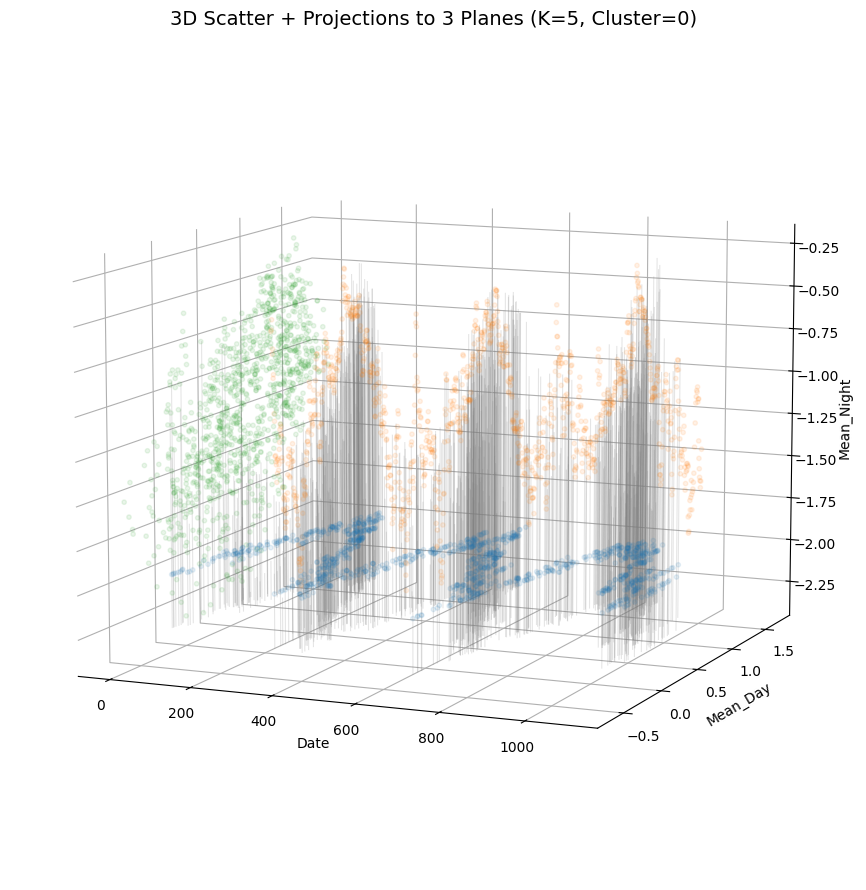

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np

def add_plane_and_projection(ax, x, y, z, plane='xy', offset_ratio=0, alpha=0.08):
    """
    添加单个投影面和平面投影点
    plane: 'xy', 'xz', 'yz'
    """
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    z_min, z_max = z.min(), z.max()

    x_range = x_max - x_min if x_max > x_min else 1
    y_range = y_max - y_min if y_max > y_min else 1
    z_range = z_max - z_min if z_max > z_min else 1

    # =============== XY 平面（Z 固定） ===============
    if plane == 'xy':
        z_plane = z_min - offset_ratio * z_range
        ax.scatter(x, y, np.full_like(x, z_plane), alpha=0.1, s=10)
        verts = [
            (x_min, y_min, z_plane),
            (x_max, y_min, z_plane),
            (x_max, y_max, z_plane),
            (x_min, y_max, z_plane)
        ]
        for xi, yi, zi in zip(x, y, z):
            ax.plot([xi, xi], [yi, yi], [zi, z_plane], color='gray', alpha=0.2, linewidth=0.8)

    # =============== XZ 平面（Y 固定） ===============
    elif plane == 'xz':
        y_plane = y_max - offset_ratio * y_range
        ax.scatter(x, np.full_like(x, y_plane), z, alpha=0.1, s=10)
        verts = [
            (x_min, y_plane, z_min),
            (x_max, y_plane, z_min),
            (x_max, y_plane, z_max),
            (x_min, y_plane, z_max)
        ]

    # =============== YZ 平面（X 固定） ===============
    elif plane == 'yz':
        x_plane = x_min - offset_ratio * x_range
        ax.scatter(np.full_like(y, x_plane), y, z, alpha=0.1, s=10)
        verts = [
            (x_plane, y_min, z_min),
            (x_plane, y_max, z_min),
            (x_plane, y_max, z_max),
            (x_plane, y_min, z_max)
        ]



def plot_3d_with_all_planes(csv_path, K, cluster, offset=10):
    df = pd.read_csv(csv_path)

    x = df["Date"].values
    y = df["Mean_Day"].values
    z = df["Mean_Night"].values

    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')

    # 原始散点
    # ax.scatter(x, y, z, s=12, alpha=0.8)

    # 三个投影面
    add_plane_and_projection(ax, x, y, z, plane='xy', offset_ratio=offset)
    add_plane_and_projection(ax, x, y, z, plane='xz', offset_ratio=offset)
    add_plane_and_projection(ax, x, y, z, plane='yz', offset_ratio=offset)

    # 标签
    ax.set_title(f"3D Scatter + Projections to 3 Planes (K={K}, Cluster={cluster})", fontsize=14)
    ax.set_xlabel("Date")
    ax.set_ylabel("Mean_Day")
    ax.set_zlabel("Mean_Night")
    ax.grid(True)
        
    # 去掉3D图外部多余的空白
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
    
    # ax.set_box_aspect([1, 1, 1])
    # 去掉背景pane（让整体更干净）
    ax.xaxis.pane.set_edgecolor('w')
    ax.yaxis.pane.set_edgecolor('w')
    ax.zaxis.pane.set_edgecolor('w')
    ax.xaxis.pane.set_alpha(0.0)
    ax.yaxis.pane.set_alpha(0.0)
    ax.zaxis.pane.set_alpha(0.0)
    # 设定视角（可按需调整）
    ax.view_init(elev=10, azim=-66.666)

    plt.tight_layout()
    plt.show()

# 使用示例
csv_path = r"D:\file\d_som\results\picture\DN\K=5\K=5_Cluster0_3D_Data.csv"
plot_3d_with_all_planes(csv_path, K=5, cluster=0, offset=0.0)
